# Praktikum Feature Selection dengan RFE, PCA, dan Kernel PCA

**Tujuan Praktikum:**
- Memahami dan implementasi **RFE (Recursive Feature Elimination)**
- Memahami dan implementasi **PCA (Principal Component Analysis)** 
- Memahami dan implementasi **Kernel PCA** untuk data non-linear
- Membandingkan performa ketiga metode pada dataset nyata

## Dataset yang Digunakan

Kita akan menggunakan **Breast Cancer Dataset** (`breast.csv`):
- **Target**: Diagnosis (M = Malignant, B = Benign)
- **Features**: 30 fitur numerik karakteristik tumor
- **Sampel**: 569 pasien
- **Sudah Clean**: Tidak perlu data cleaning lagi

In [1]:
# Import Library yang Dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA, KernelPCA
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
 
# Set random state untuk reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot styling
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Library berhasil diimport")
print(f"✓ Random state di-set ke: {RANDOM_STATE}")

✓ Library berhasil diimport
✓ Random state di-set ke: 42


In [2]:
# Baca file CSV
df = pd.read_csv('breast.csv')
print(f"📊 Shape dataset asli: {df.shape}")

📊 Shape dataset asli: (569, 33)


In [3]:
# Hapus kolom yang tidak diperlukan (id dan Unnamed: 32)
columns_to_drop = ['id', 'Unnamed: 32']
df_clean = df.drop(columns=columns_to_drop, errors='ignore')
print(f"📊 Shape setelah cleaning: {df_clean.shape}")

# Cek missing values
print(f"🔍 Missing values setelah cleaning: {df_clean.isnull().sum().sum()}")

# Tampilkan 5 baris pertama
print("\n📄 5 baris pertama:")
display(df_clean.head())

# Distribusi target
print(f"\n🎯 Distribusi Target:")
print(df_clean['diagnosis'].value_counts())

📊 Shape setelah cleaning: (569, 31)
🔍 Missing values setelah cleaning: 0

📄 5 baris pertama:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



🎯 Distribusi Target:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [4]:
# Pisahkan features dan target
X = df_clean.drop(['diagnosis'], axis=1)  # Features (30 kolom)
y = df_clean['diagnosis']  # Target

# Encoding target: M = 1, B = 0
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"✅ Features shape: {X.shape}")
print(f"✅ Target shape: {y_encoded.shape}")
print(f"✅ Benign (0): {(y_encoded == 0).sum()} samples")
print(f"✅ Malignant (1): {(y_encoded == 1).sum()} samples")
print(f"✅ Missing values: {X.isnull().sum().sum()}")

✅ Features shape: (569, 30)
✅ Target shape: (569,)
✅ Benign (0): 357 samples
✅ Malignant (1): 212 samples
✅ Missing values: 0


In [5]:
# Tampilkan beberapa fitur pertama
print(f"\n📊 Sample features:")
display(X.iloc[:3, :5])

# Statistik dasar
print(f"\n📈 Data Statistics:")
print(f"   Mean: {X.values.mean():.2f}")
print(f"   Std: {X.values.std():.2f}")
print(f"   Min: {X.values.min():.2f}")
print(f"   Max: {X.values.max():.2f}")


📊 Sample features:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean
0,17.99,10.38,122.8,1001.0,0.11840
1,20.57,17.77,132.9,1326.0,0.08474
2,19.69,21.25,130.0,1203.0,0.10960



📈 Data Statistics:
   Mean: 61.89
   Std: 228.30
   Min: 0.00
   Max: 4254.00


# 1. Recursive Feature Elimination (RFE)

**RFE** adalah metode feature selection yang:
- Menggunakan model machine learning untuk mengevaluasi fitur
- Menghapus fitur yang paling tidak penting secara iteratif
- Memilih fitur dengan importance tertinggi

**Algoritma RFE:**
1. Train model dengan semua fitur
2. Hitung feature importance
3. Hapus fitur dengan importance terendah
4. Ulangi sampai target jumlah fitur tercapai

In [6]:
# RFE Implementation
print("🔄 RFE (Recursive Feature Elimination)")
print("=" * 50)

# Setup Random Forest untuk RFE
rf_estimator = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

# RFE untuk memilih 10 fitur terbaik
rfe = RFE(estimator=rf_estimator, n_features_to_select=10, step=1)

# Fit RFE ke data
rfe.fit(X, y_encoded)

print(f"RFE selesai dengan {rfe.n_features_} fitur terpilih")

# Tampilkan hasil seleksi
rfe_results = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print("\n📋 10 Fitur Terpilih (Ranking = 1):")
selected_features = rfe_results[rfe_results['Selected'] == True]
display(selected_features[['Feature', 'Ranking']])

print(f"\n❌ Fitur yang Dihapus (Ranking > 1):")
rejected_features = rfe_results[rfe_results['Ranking'] > 1].head(5)
display(rejected_features[['Feature', 'Ranking']])

🔄 RFE (Recursive Feature Elimination)
RFE selesai dengan 10 fitur terpilih

📋 10 Fitur Terpilih (Ranking = 1):


,Feature,Ranking
26,concavity_worst,1
22,perimeter_worst,1
23,area_worst,1
21,texture_worst,1
27,concave points_worst,1
7,concave points_mean,1
20,radius_worst,1
3,area_mean,1
2,perimeter_mean,1
6,concavity_mean,1



❌ Fitur yang Dihapus (Ranking > 1):


,Feature,Ranking
24,smoothness_worst,2
0,radius_mean,3
13,area_se,4
1,texture_mean,5
25,compactness_worst,6


Visualisasi Hasil RFE


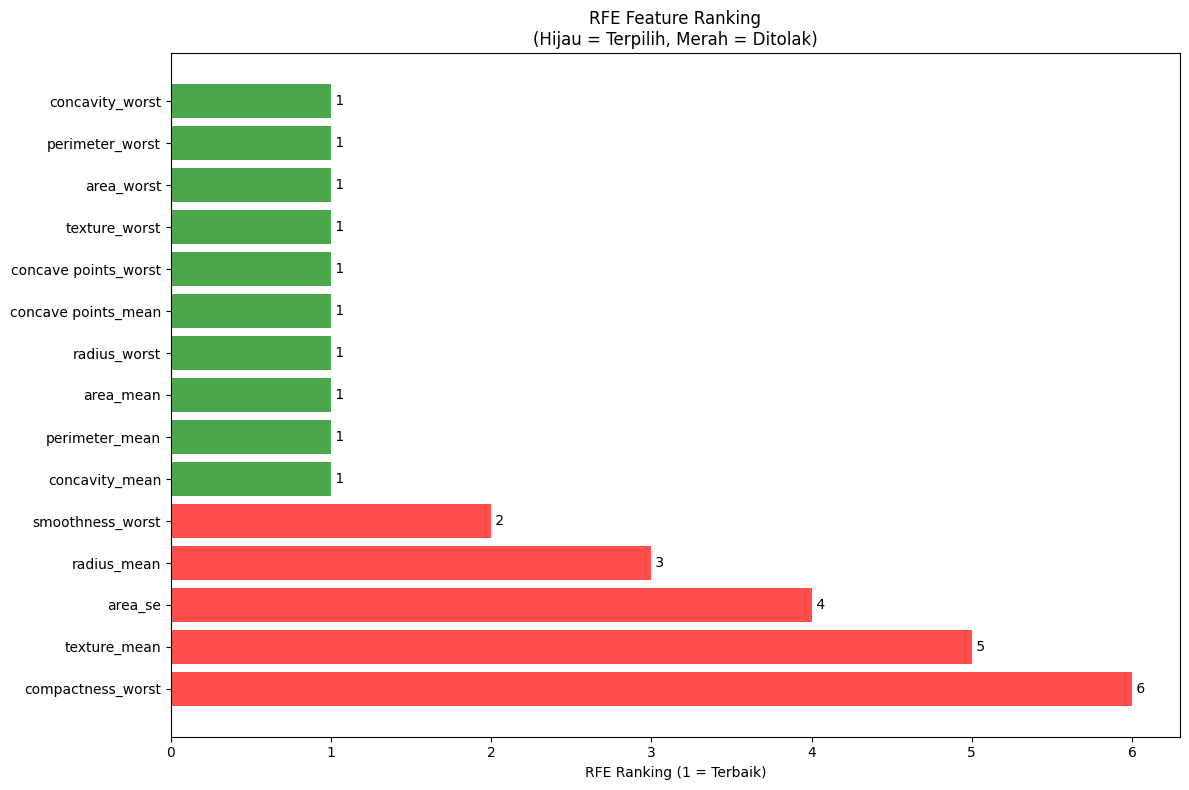


💡 Insight:
- Total fitur asli: 30
- Fitur terpilih: 10
- Reduksi fitur: 66.7%


In [7]:
# Visualisasi RFE Results
print("Visualisasi Hasil RFE")

# Plot 15 fitur teratas
plt.figure(figsize=(12, 8))
top_features = rfe_results.head(15)
colors = ['green' if rank == 1 else 'red' for rank in top_features['Ranking']]

bars = plt.barh(range(len(top_features)), top_features['Ranking'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('RFE Ranking (1 = Terbaik)')
plt.title('RFE Feature Ranking\n(Hijau = Terpilih, Merah = Ditolak)')
plt.gca().invert_yaxis()

# Tambahkan nilai ranking di bar
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f' {int(width)}', ha='left', va='center')

plt.tight_layout()
plt.show()

print(f"\n💡 Insight:")
print(f"- Total fitur asli: {len(X.columns)}")
print(f"- Fitur terpilih: {rfe.n_features_}")
print(f"- Reduksi fitur: {100 * (1 - rfe.n_features_/len(X.columns)):.1f}%")

# 2. Principal Component Analysis (PCA)

**PCA** adalah teknik dimensionality reduction yang:
- Mengubah fitur asli menjadi komponen utama (principal components)
- Komponen pertama menangkap varians maksimal data
- Mengurangi dimensi dengan meminimalisir kehilangan informasi
- Membantu menghilangkan multicollinearity

**Manfaat PCA:**
- Reduksi dimensi (dari 30 fitur → lebih sedikit komponen)
- Menghilangkan korelasi antar fitur
- Mempercepat training model
- Visualisasi high-dimensional data

In [8]:
# Data Scaling untuk PCA
print("Data Scaling untuk PCA")
print("=" * 30)

# Standardisasi data (penting untuk PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Data Scaling untuk PCA


In [9]:
# PCA dengan semua komponen untuk analisis
pca_full = PCA()
pca_full.fit(X_scaled)

# Analisis explained variance
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Tentukan jumlah komponen untuk 90% dan 95% varians
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Analisis Varians:")
print(f"   Komponen untuk 90% varians: {n_components_90}")
print(f"   Komponen untuk 95% varians: {n_components_95}")

# Tampilkan 10 komponen pertama
pca_summary = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(10)],
    'Explained Variance': explained_variance_ratio[:10],
    'Cumulative Variance': cumulative_variance[:10]
})

pca_summary['Explained Variance %'] = (pca_summary['Explained Variance'] * 100).round(2)
pca_summary['Cumulative Variance %'] = (pca_summary['Cumulative Variance'] * 100).round(2)

print("\n10 Komponen Pertama:")
display(pca_summary)

Analisis Varians:
   Komponen untuk 90% varians: 7
   Komponen untuk 95% varians: 10

10 Komponen Pertama:


,PC,Explained Variance,Cumulative Variance,Explained Variance %,Cumulative Variance %
0,PC1,0.442720,0.442720,44.27,44.27
1,PC2,0.189712,0.632432,18.97,63.24
2,PC3,0.093932,0.726364,9.39,72.64
3,PC4,0.066021,0.792385,6.60,79.24
4,PC5,0.054958,0.847343,5.50,84.73
5,PC6,0.040245,0.887588,4.02,88.76
6,PC7,0.022507,0.910095,2.25,91.01
7,PC8,0.015887,0.925983,1.59,92.60
8,PC9,0.013896,0.939879,1.39,93.99
9,PC10,0.011690,0.951569,1.17,95.16


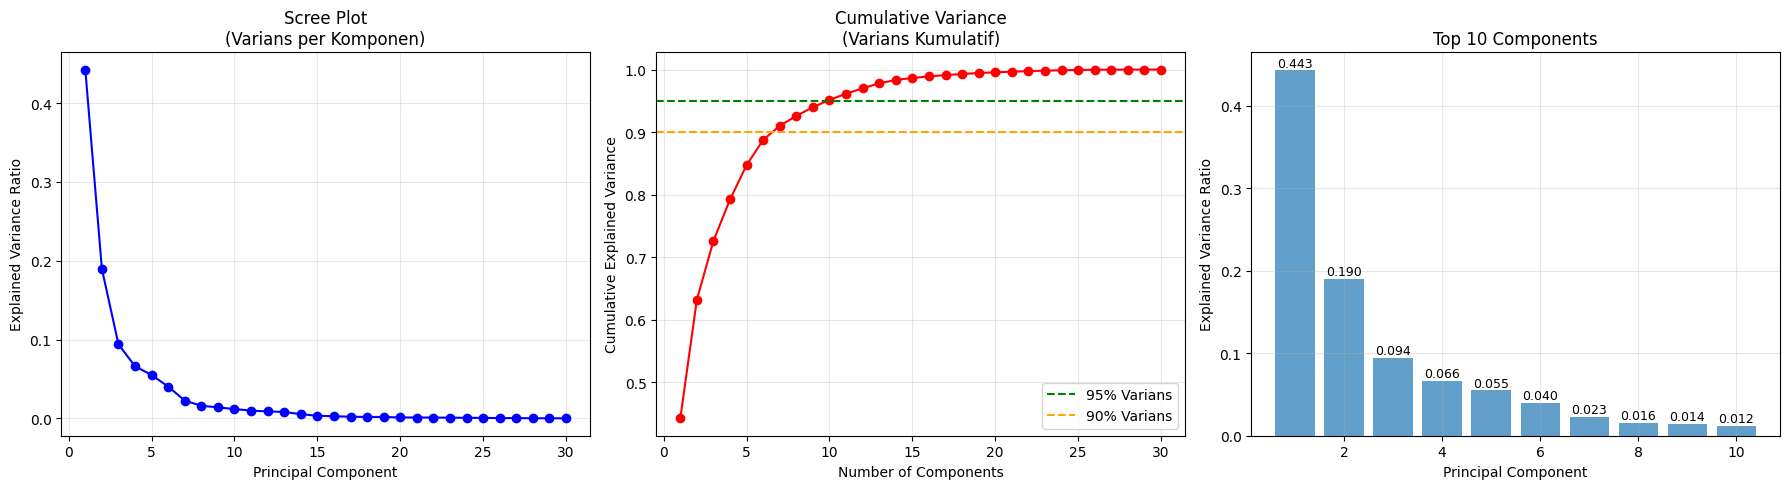

In [10]:
# Visualisasi PCA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scree Plot
axes[0].plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, 'bo-')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot\n(Varians per Komponen)')
axes[0].grid(True, alpha=0.3)

# 2. Cumulative Variance
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'ro-')
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95% Varians')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% Varians')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance\n(Varians Kumulatif)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Individual Components (Top 10)
n_show = 10
bars = axes[2].bar(range(1, n_show+1), explained_variance_ratio[:n_show], alpha=0.7)
axes[2].set_xlabel('Principal Component')
axes[2].set_ylabel('Explained Variance Ratio')
axes[2].set_title('Top 10 Components')
axes[2].grid(True, alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

🎯 PCA Transformasi & Visualisasi
✅ Shape data 2D: (569, 2)
✅ Varians yang dijaga: 63.2%
✅ PC1 varians: 44.3%
✅ PC2 varians: 19.0%


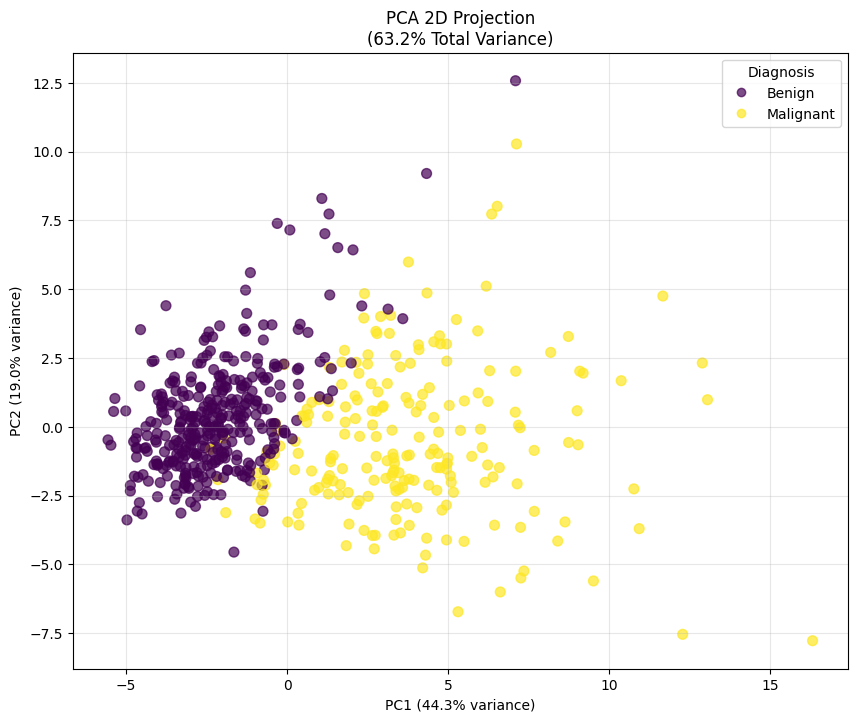

In [11]:
# PCA Transformasi dan 2D Visualization
print("🎯 PCA Transformasi & Visualisasi")
print("=" * 40)

# Transformasi dengan 2 komponen untuk visualisasi
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"✅ Shape data 2D: {X_pca_2d.shape}")
print(f"✅ Varians yang dijaga: {pca_2d.explained_variance_ratio_.sum():.1%}")
print(f"✅ PC1 varians: {pca_2d.explained_variance_ratio_[0]:.1%}")
print(f"✅ PC2 varians: {pca_2d.explained_variance_ratio_[1]:.1%}")

# Visualisasi 2D
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                     c=y_encoded, cmap='viridis', alpha=0.7, s=50)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'PCA 2D Projection\n({pca_2d.explained_variance_ratio_.sum():.1%} Total Variance)')

# Add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, ['Benign', 'Malignant'], title='Diagnosis')
plt.grid(True, alpha=0.3)
plt.show()

🎯 PCA 3D Visualization
✅ Shape data 3D: (569, 3)
✅ Varians yang dijaga: 72.6%
✅ PC1 varians: 44.3%
✅ PC2 varians: 19.0%
✅ PC3 varians: 9.4%


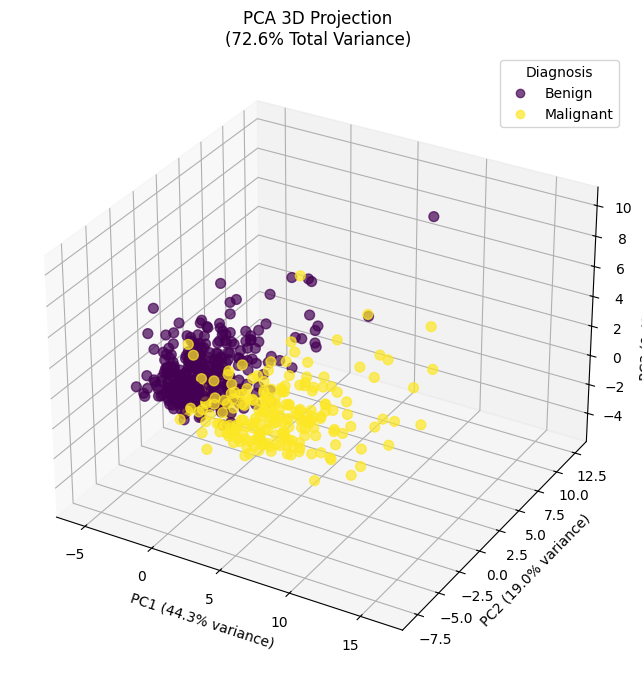

In [ ]:
# Misal ada kasus PCA Transformasi (3)
# 3D Visualization with PCA
print("🎯 PCA 3D Visualization")
print("=" * 40)
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)
print(f"✅ Shape data 3D: {X_pca_3d.shape}")
print(f"✅ Varians yang dijaga: {pca_3d.explained_variance_ratio_.sum():.1%}")
print(f"✅ PC1 varians: {pca_3d.explained_variance_ratio_[0]:.1%}")
print(f"✅ PC2 varians: {pca_3d.explained_variance_ratio_[1]:.1%}")
print(f"✅ PC3 varians: {pca_3d.explained_variance_ratio_[2]:.1%}")
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                     c=y_encoded, cmap='viridis', alpha=0.7, s=50)
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%} variance)')  

ax.set_title(f'PCA 3D Projection\n({pca_3d.explained_variance_ratio_.sum():.1%} Total Variance)')
handles, labels = scatter.legend_elements()
ax.legend(handles, ['Benign', 'Malignant'], title='Diagnosis')
plt.show()


🎯 PCA Pair Plot (3 Komponen)


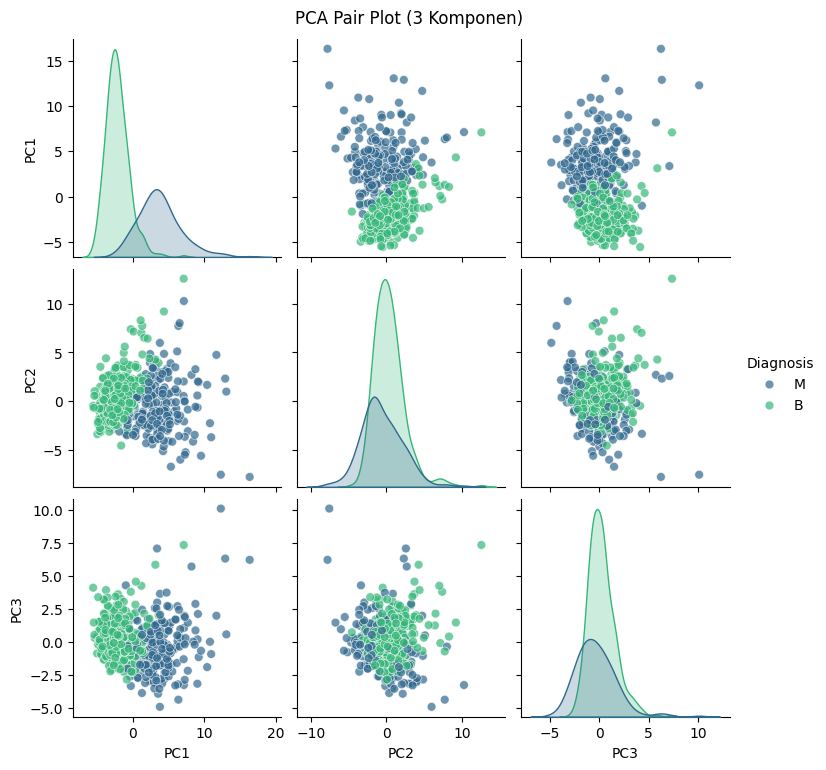

In [19]:
# PCA 3 Components Pair Plot
print("🎯 PCA Pair Plot (3 Komponen)")
print("=" * 40)
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)
pca_3_df = pd.DataFrame(data=X_pca_3, columns=['PC1', 'PC2', 'PC3'])
pca_3_df['Diagnosis'] = y.values
sns.pairplot(pca_3_df, hue='Diagnosis', diag_kind='kde', palette='viridis', plot_kws={'alpha':0.7, 's':40})
plt.suptitle('PCA Pair Plot (3 Komponen)', y=1.02)
plt.show()

🎯 PCA Transformasi (4 Komponen)
✅ Shape data: (569, 4)
✅ Total Varians dijaga: 79.2%
--------------------
   PC1: 44.3%
   PC2: 19.0%
   PC3: 9.4%
   PC4: 6.6%

📊 Memunculkan Pair Plot...


<Figure size 1500x1500 with 0 Axes>

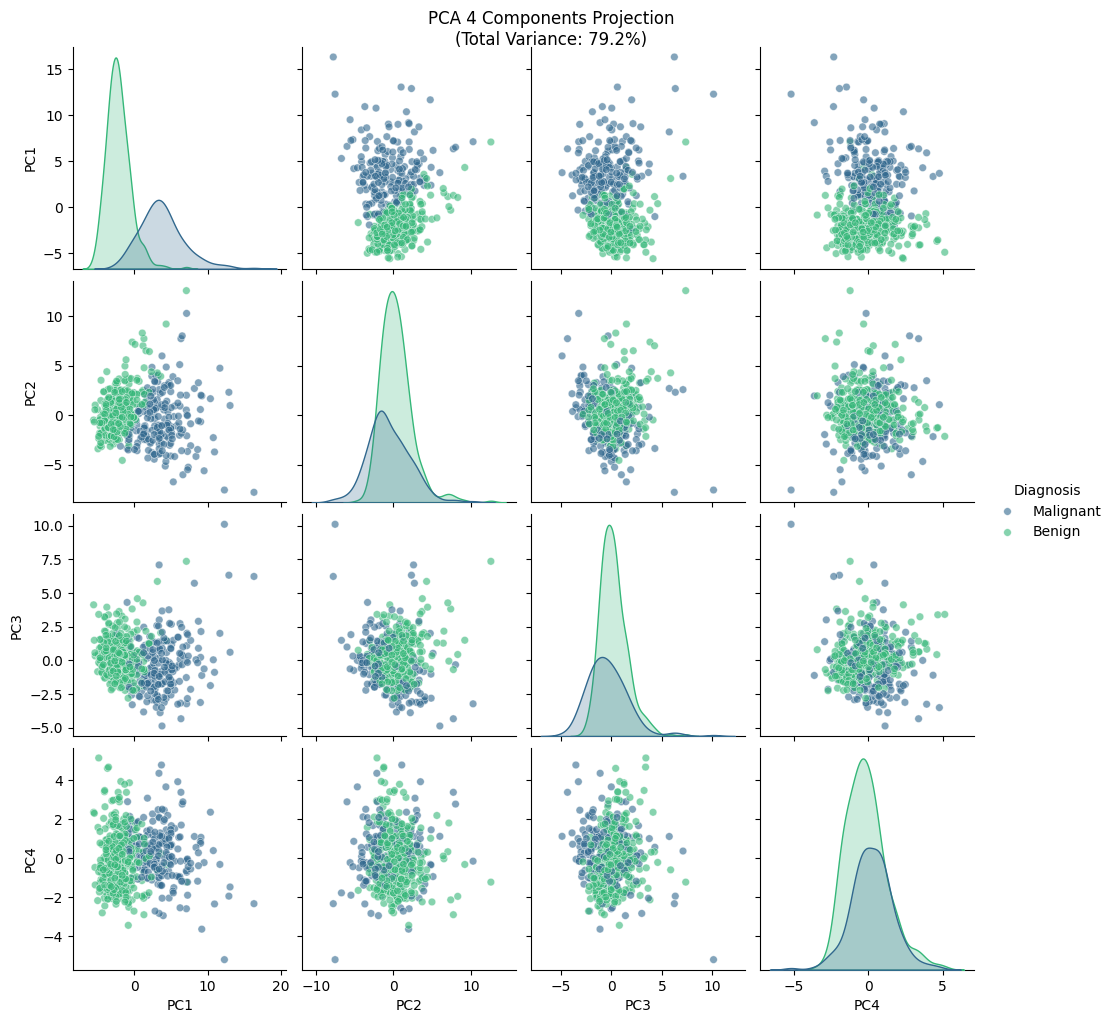

In [ ]:
# Misal ada kasus PCA Transformasi (4) 
# (hanya bisa pair plot dan cek explained variance), (Gabisa 4d plot karena keterbatasan visualisasi)

print("🎯 PCA Transformasi (4 Komponen)")
print("=" * 40)

pca_4d = PCA(n_components=4)
X_pca_4d = pca_4d.fit_transform(X_scaled)

# Cek Varians
print(f"✅ Shape data: {X_pca_4d.shape}")
print(f"✅ Total Varians dijaga: {pca_4d.explained_variance_ratio_.sum():.1%}")
print("-" * 20)
for i, var in enumerate(pca_4d.explained_variance_ratio_):
    print(f"   PC{i+1}: {var:.1%}")

# ---------------------------------------------------------
# 2. Visualisasi (Gunakan Pair Plot)
# ---------------------------------------------------------
# Kita harus buat DataFrame dulu agar mudah di-plot oleh Seaborn
df_pca = pd.DataFrame(X_pca_4d, columns=['PC1', 'PC2', 'PC3', 'PC4'])

# Tambahkan kolom diagnosis (target) untuk pewarnaan
# Jika y_encoded isinya 0 dan 1, kita mapping biar legend-nya bagus
df_pca['Diagnosis'] = ['Malignant' if x == 1 else 'Benign' for x in y_encoded] 
# Catatan: Sesuaikan logic 'if x == 1' dengan encoding datamu (mana yg ganas mana yg jinak)

print("\n📊 Memunculkan Pair Plot...")

# Plotting
plt.figure(figsize=(15, 15))
pairplot = sns.pairplot(df_pca, 
                        hue='Diagnosis',      # Warna berdasarkan target
                        palette='viridis',    # Tema warna
                        diag_kind='kde',      # Gambar gunung di diagonal
                        plot_kws={'alpha': 0.6, 's': 30}) # Transparansi & ukuran titik

pairplot.fig.suptitle(f'PCA 4 Components Projection\n(Total Variance: {pca_4d.explained_variance_ratio_.sum():.1%})', y=1.02)
plt.show()

# 3. Kernel PCA

**Kernel PCA** adalah ekstensi dari PCA untuk data non-linear:
- Menggunakan kernel functions untuk mapping ke high-dimensional space
- Dapat menangkap struktur data non-linear yang tidak terdeteksi PCA biasa
- Jenis kernel: RBF, polynomial, sigmoid

**Kernel Functions:**
- **RBF**: $K(x,y) = \exp(-\gamma||x-y||^2)$ - untuk pola radial
- **Polynomial**: $K(x,y) = (x^Ty + c)^d$ - untuk hubungan polinomial
- **Sigmoid**: $K(x,y) = \tanh(\gamma x^Ty + c)$ - untuk neural network-like

In [14]:
# Kernel PCA Implementation
print("🌀 Kernel PCA Implementation")
print("=" * 50)

# Test berbagai kernel untuk 2D visualisasi
kernels = {
    'RBF (γ=0.1)': KernelPCA(n_components=2, kernel='rbf', gamma=0.1, random_state=RANDOM_STATE),
    'RBF (γ=5)': KernelPCA(n_components=2, kernel='rbf', gamma=5, random_state=RANDOM_STATE),
    'Polynomial (d=3)': KernelPCA(n_components=2, kernel='poly', degree=3, random_state=RANDOM_STATE),
    'Sigmoid': KernelPCA(n_components=2, kernel='sigmoid', gamma=0.001, random_state=RANDOM_STATE)
}

# Transformasi data dengan setiap kernel
kernel_results = {}
for name, kpca in kernels.items():
    try:
        X_kpca = kpca.fit_transform(X_scaled)
        kernel_results[name] = X_kpca
        print(f"✅ {name}: Shape = {X_kpca.shape}")
    except Exception as e:
        print(f"❌ {name}: Error - {str(e)}")

print(f"\n📊 Berhasil mentransformasi dengan {len(kernel_results)} kernel")

🌀 Kernel PCA Implementation
✅ RBF (γ=0.1): Shape = (569, 2)
✅ RBF (γ=5): Shape = (569, 2)
✅ Polynomial (d=3): Shape = (569, 2)
✅ Sigmoid: Shape = (569, 2)

📊 Berhasil mentransformasi dengan 4 kernel


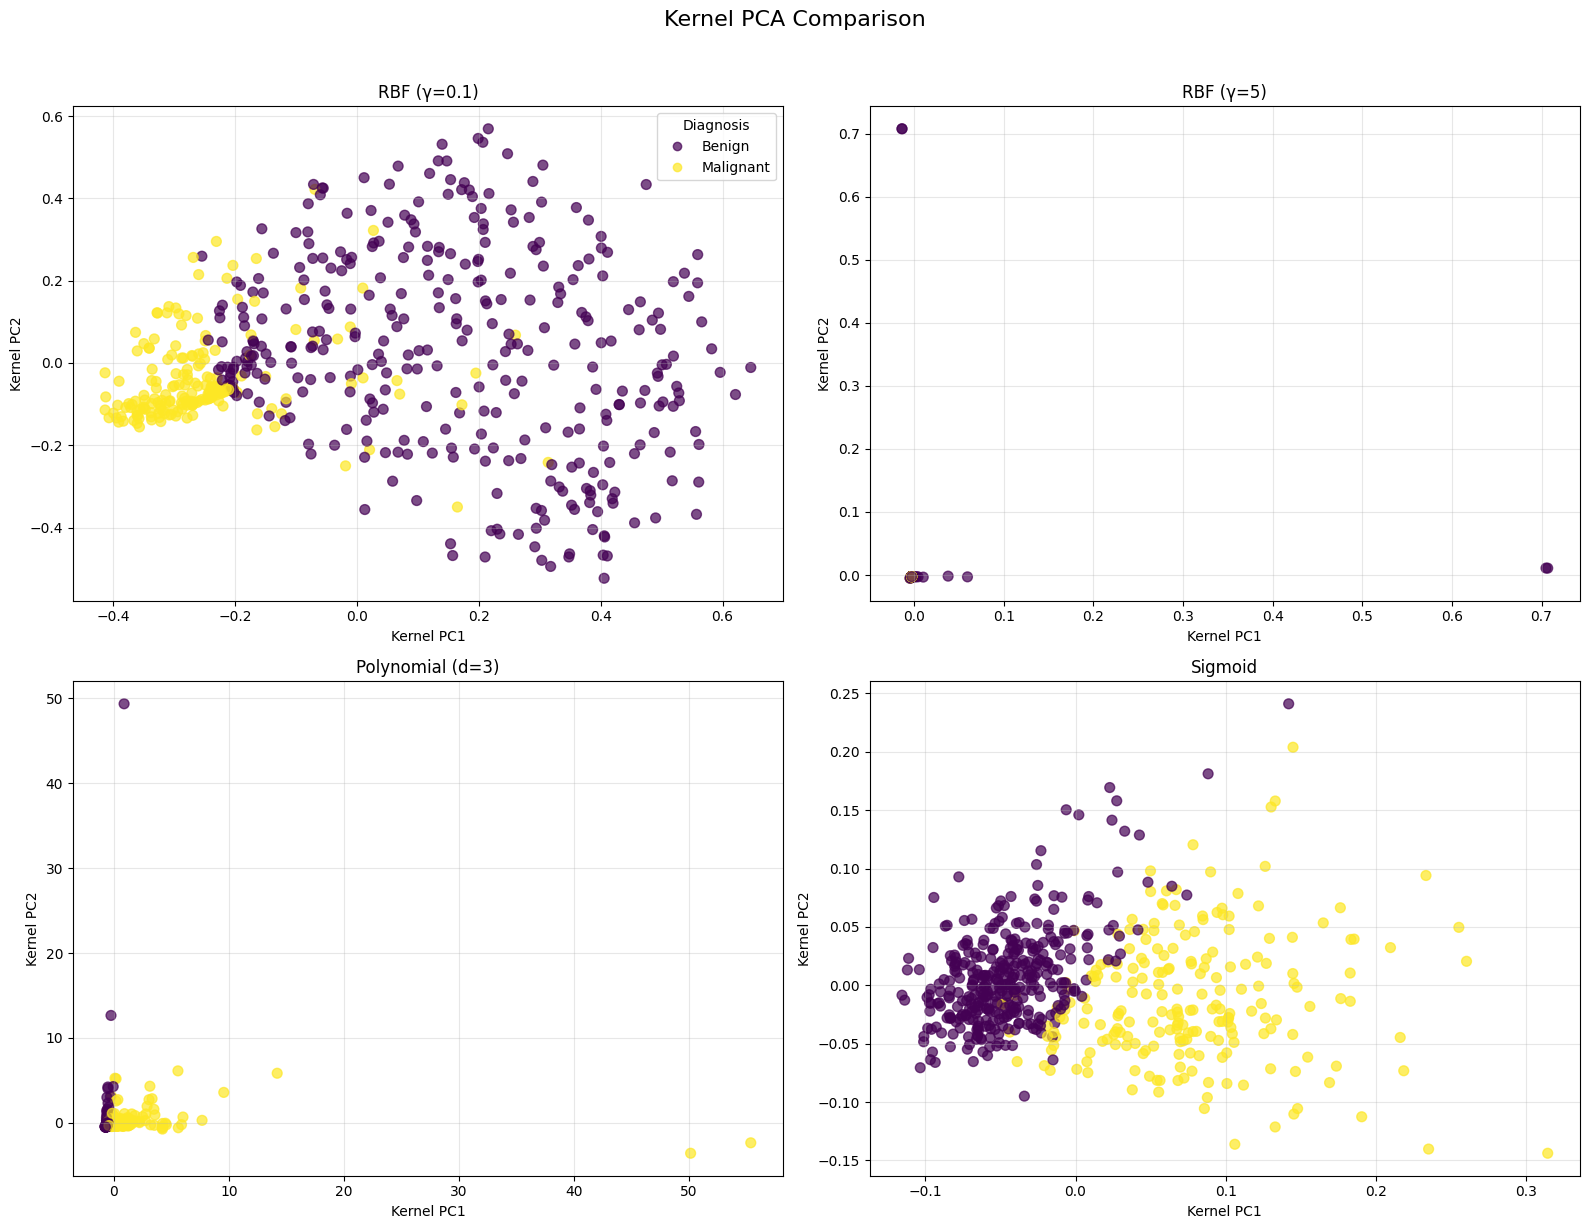

In [15]:
# Visualisasi Kernel PCA Results
if len(kernel_results) > 0:
    n_kernels = len(kernel_results)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Kernel PCA Comparison', fontsize=16, y=1.02)
    
    for idx, (name, X_kpca) in enumerate(kernel_results.items()):
        if idx < 4:
            row = idx // 2
            col = idx % 2
            
            scatter = axes[row, col].scatter(X_kpca[:, 0], X_kpca[:, 1], 
                                         c=y_encoded, cmap='viridis', alpha=0.7, s=50)
            axes[row, col].set_xlabel('Kernel PC1')
            axes[row, col].set_ylabel('Kernel PC2')
            axes[row, col].set_title(f'{name}')
            axes[row, col].grid(True, alpha=0.3)
            
            # Add legend
            if idx == 0:
                handles, labels = scatter.legend_elements()
                axes[row, col].legend(handles, ['Benign', 'Malignant'], title='Diagnosis')
    
    # Hide unused subplots
    for idx in range(len(kernel_results), 4):
        row = idx // 2
        col = idx % 2
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ Tidak ada kernel PCA yang berhasil dijalankan")

# 4. Perbandingan Performa Model

Kita akan membandingkan performa model Logistic Regression dengan:
1. **Baseline**: Semua 30 fitur
2. **RFE**: 10 fitur terpilih
3. **PCA**: 10 komponen (90% varians)
4. **Kernel PCA**: 2 komponen dengan RBF kernel (γ=15)

In [16]:
# Model Performance Comparison
print("🏁 Model Performance Comparison")
print("=" * 50)

# Setup model dan cross-validation
model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results_data = []

# 1. Baseline - All features (30)
print("🔄 1. Baseline - All Features...")
pipeline_baseline = make_pipeline(StandardScaler(), model)
scores_baseline = cross_val_score(pipeline_baseline, X, y_encoded, cv=cv, scoring='accuracy')
results_data.append(['Baseline (All Features)', 30, scores_baseline.mean(), scores_baseline.std()])
print(f"   Accuracy: {scores_baseline.mean():.4f} ± {scores_baseline.std():.4f}")

# 2. RFE - 10 selected features
print("🔄 2. RFE - Selected Features...")
rfe_features = rfe_results[rfe_results['Selected'] == True]['Feature'].tolist()
X_rfe = X[rfe_features]
pipeline_rfe = make_pipeline(StandardScaler(), model)
scores_rfe = cross_val_score(pipeline_rfe, X_rfe, y_encoded, cv=cv, scoring='accuracy')
results_data.append(['RFE (10 Features)', 10, scores_rfe.mean(), scores_rfe.std()])
print(f"   Accuracy: {scores_rfe.mean():.4f} ± {scores_rfe.std():.4f}")

# 3. PCA - 10 components (90% variance)
print("🔄 3. PCA - Components...")
pipeline_pca = make_pipeline(StandardScaler(), PCA(n_components=10), model)
scores_pca = cross_val_score(pipeline_pca, X, y_encoded, cv=cv, scoring='accuracy')
results_data.append(['PCA (10 Components)', 10, scores_pca.mean(), scores_pca.std()])
print(f"   Accuracy: {scores_pca.mean():.4f} ± {scores_pca.std():.4f}")

# 4. Kernel PCA - 2 components (RBF)
print("🔄 4. Kernel PCA - RBF...")
if 'RBF (γ=15)' in kernel_results:
    # Convert kernel PCA result back to DataFrame for pipeline
    X_kpca = kernel_results['RBF (γ=15)']
    pipeline_kpca = make_pipeline(model)  # No scaling needed for KPCA results
    scores_kpca = cross_val_score(pipeline_kpca, X_kpca, y_encoded, cv=cv, scoring='accuracy')
    results_data.append(['Kernel PCA (RBF, 2 Components)', 2, scores_kpca.mean(), scores_kpca.std()])
    print(f"   Accuracy: {scores_kpca.mean():.4f} ± {scores_kpca.std():.4f}")
else:
    print("   ❌ Kernel PCA failed, skipping...")

print("\n✅ Cross-validation selesai untuk semua metode")

🏁 Model Performance Comparison
🔄 1. Baseline - All Features...
   Accuracy: 0.9737 ± 0.0166
🔄 2. RFE - Selected Features...
   Accuracy: 0.9719 ± 0.0151
🔄 3. PCA - Components...
   Accuracy: 0.9772 ± 0.0070
🔄 4. Kernel PCA - RBF...
   ❌ Kernel PCA failed, skipping...

✅ Cross-validation selesai untuk semua metode


In [17]:
# Results Summary
results = pd.DataFrame(results_data, columns=['Method', 'Features/Components', 'Mean Accuracy', 'Std Accuracy'])

# Add calculated columns
results['Accuracy %'] = (results['Mean Accuracy'] * 100).round(2)
results['Reduction %'] = ((30 - results['Features/Components']) / 30 * 100).round(1)
results['Performance Drop %'] = ((results['Mean Accuracy'].iloc[0] - results['Mean Accuracy']) / results['Mean Accuracy'].iloc[0] * 100).round(2)

print("📊 Model Performance Comparison:")
display(results[['Method', 'Features/Components', 'Accuracy %', 'Reduction %', 'Performance Drop %']])

# Find best method
best_method = results.loc[results['Mean Accuracy'].idxmax()]
print(f"\n🏆 Best Method: {best_method['Method']}")
print(f"   Accuracy: {best_method['Mean Accuracy']:.4f} ({best_method['Accuracy %']}%)")
print(f"   Feature Reduction: {best_method['Reduction %']}%")

# Most efficient method (best balance)
efficient_methods = results[results['Performance Drop %'] < 5]
if len(efficient_methods) > 0:
    most_efficient = efficient_methods.loc[efficient_methods['Reduction %'].idxmax()]
    print(f"\n⚖️ Most Efficient: {most_efficient['Method']}")
    print(f"   Accuracy: {most_efficient['Mean Accuracy']:.4f} (drop: {most_efficient['Performance Drop %']}%)")
    print(f"   Reduction: {most_efficient['Reduction %']}%")

📊 Model Performance Comparison:


,Method,Features/Components,Accuracy %,Reduction %,Performance Drop %
0,Baseline (All Features),30,97.37,0.0,0.00
1,RFE (10 Features),10,97.19,66.7,0.18
2,PCA (10 Components),10,97.72,66.7,-0.36



🏆 Best Method: PCA (10 Components)
   Accuracy: 0.9772 (97.72%)
   Feature Reduction: 66.7%

⚖️ Most Efficient: RFE (10 Features)
   Accuracy: 0.9719 (drop: 0.18%)
   Reduction: 66.7%


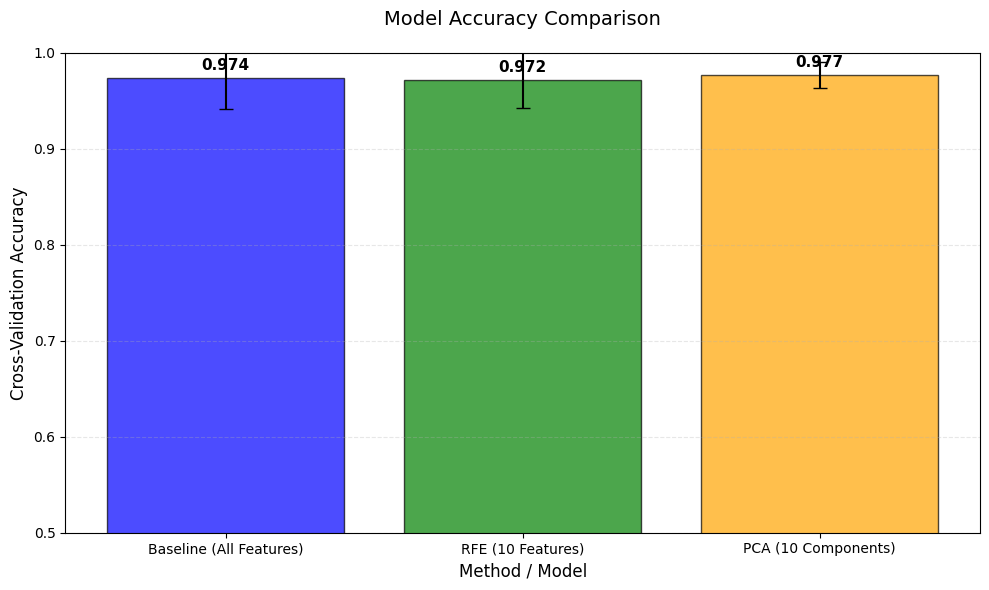

In [18]:
plt.figure(figsize=(10, 6))

# Tentukan warna (sesuai jumlah model yang ada)
colors = ['blue', 'green', 'orange', 'red', 'purple'][:len(results)]

# Plotting Bar Chart
bars = plt.bar(results['Method'], results['Mean Accuracy'], 
              yerr=1.96*results['Std Accuracy'], # Error bar (Confidence Interval)
              capsize=5, 
              alpha=0.7, 
              color=colors,
              edgecolor='black')

# Formatting Visual
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.xlabel('Method / Model', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, pad=20)
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.3) # Grid hanya horizontal biar rapi

# --- Fitur Tambahan: Menampilkan Angka Akurasi di Atas Batang ---
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}',  # Format 3 angka desimal
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Kesimpulan dan Insights

## 📋 Summary Results

### RFE (Recursive Feature Elimination)
✅ **Kelebihan:**
- Memilih fitur yang paling penting secara interpretatif
- Hasil fitur masih dapat dijelaskan domain knowledge
- Performa sangat baik
- Reduksi fitur dengan drop performa minimal

❌ **Kekurangan:**
- Komputasi lebih lama untuk dataset besar
- Hasil tergantung pada model yang digunakan untuk RFE

### PCA (Principal Component Analysis)
✅ **Kelebihan:**
- Komputasi cepat
- Menghilangkan multicollinearity
- Reduksi dimensi efektif
- Komponen tidak berkorelasi

❌ **Kekurangan:**
- Komponen sulit diinterpretasi (black box)
- Hilangnya makna fitur asli
- Hanya menangkap hubungan linear

### Kernel PCA
✅ **Kelebihan:**
- Dapat menangkap struktur non-linear
- Fleksibel dengan berbagai kernel
- Baik untuk visualisasi data kompleks

❌ **Kekurangan:**
- Pemilihan parameter sulit
- Tidak ada inverse transform
- Komputasi lebih berat
- Risk overfitting dengan parameter yang salah

## 🎯 Rekomendasi Praktis

### **Gunakan RFE jika:**
- ✅ Butuh interpretasi fitur
- ✅ Performa model adalah priority
- ✅ Dataset tidak terlalu besar (<1000 fitur)
- ✅ Ada waktu komputasi

### **Gunakan PCA jika:**
- ✅ Fitur highly correlated
- ✅ Butuh reduksi dimensi besar
- ✅ Model sensitif terhadap multicollinearity
- ✅ Kecepatan komputasi penting

### **Gunakan Kernel PCA jika:**
- ✅ Data memiliki struktur non-linear
- ✅ PCA biasa tidak optimal
- ✅ Visualisasi high-dimensional data
- ✅ Eksplorasi pola tersembunyi

**Final Recommendation:** Pilih metode berdasarkan kebutuhan:
- **Interpretasi**: RFE
- **Komputasi cepat**: PCA
- **Eksplorasi non-linear**: Kernel PCA